<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MineriaDatos_S7_Repaso_S1S6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0D1B2A;color:white;padding:30px 40px;border-radius:12px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:13px;letter-spacing:2px;margin:0;">MINERÍA DE DATOS · 2026 · SEMANA 7</p>
  <h1 style="font-size:34px;margin:10px 0 6px 0;color:#FFFFFF;">Notebook de Repaso Integral</h1>
  <h2 style="font-size:20px;color:#A8D8EA;font-weight:300;margin:0 0 20px 0;">Semanas 1 a 6: De la Introducción al Clustering</h2>
  <hr style="border:1px solid #1C7293;margin:18px 0;">
  <p style="color:#8BADC0;font-size:13px;margin:0;">Nombre: _____________________________ &nbsp;&nbsp; Fecha: _____________</p>
</div>

> **Objetivo de este notebook:** Repasar y consolidar los conceptos trabajados durante las primeras 6 semanas de la materia, resolviendo ejercicios prácticos sobre cada bloque temático.
>
> **Cómo usarlo:** Cada sección corresponde a una semana. Completá los bloques `# TODO` con tu código, ejecutá las celdas y reflexioná sobre los resultados.


---
## ⚙️ Configuración inicial
Ejecutá esta celda primero. Importa todas las librerías y carga los datasets que se usarán a lo largo del repaso.


In [ ]:
# ── Librerías generales ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Estilo visual unificado
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

# ── Dataset principal: Titanic ────────────────────────────────────────
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url_titanic)

# ── Dataset secundario: Wine (para clustering) ────────────────────────
from sklearn.datasets import load_wine
wine_data = load_wine()
df_wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
df_wine["variedad"] = wine_data.target  # 0, 1, 2 — no la usamos en clustering

print(f"Titanic: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Wine:    {df_wine.shape[0]} filas × {df_wine.shape[1]} columnas")
print("\n✅ Todo listo para el repaso.")


Titanic: 891 filas × 12 columnas
Wine:    178 filas × 14 columnas

✅ Todo listo para el repaso.


---
# 📦 SEMANA 1 — Introducción a la Minería de Datos y Herramientas

**Temas de la semana:**
- Evolución histórica de la minería de datos
- Proceso KDD (Knowledge Discovery in Databases)
- Python, Pandas, Google Colab y JupyterLab

### ¿Qué es KDD?
KDD (Knowledge Discovery in Databases) es el proceso completo de extraer conocimiento útil desde grandes conjuntos de datos. Consta de etapas secuenciales:

| Etapa | Descripción |
|-------|-------------|
| 1. Selección | Elegir los datos relevantes del problema |
| 2. Preprocesamiento | Limpiar, manejar nulos y outliers |
| 3. Transformación | Normalizar, codificar, crear features |
| 4. Minería | Aplicar el algoritmo (clustering, clasificación...) |
| 5. Evaluación e Interpretación | Validar resultados y comunicar conclusiones |


### 1.1 Exploración inicial del dataset
La primera etapa del proceso KDD es entender con qué datos trabajamos. Las funciones `head()`, `info()` y `shape` son las primeras herramientas.


In [ ]:
# ── Exploración inicial ───────────────────────────────────────────────
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== INFORMACIÓN GENERAL ===")
df.info()

print(f"\n=== FORMA DEL DATASET ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")


=== PRIMERAS FILAS ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== FORMA DEL DATASET ===
Filas: 891 | Columnas: 12


### 1.2 Ejercicio — Ubicar el dataset en el proceso KDD


In [ ]:
# TODO: Respondé en comentarios
# 1. ¿Qué información contiene el dataset Titanic?
#    R:

# 2. ¿En qué etapa del proceso KDD estamos cuando ejecutamos df.head()?
#    R:

# 3. ¿Cuáles columnas parecen más útiles para predecir si un pasajero sobrevivió?
#    R:

# 4. ¿Qué columnas tienen valores faltantes? (usá df.isnull().sum())
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


---
# 📊 SEMANA 2 — Tipos de Datos y Estadística Descriptiva

**Temas de la semana:**
- Clasificación de datos: estructurados vs no estructurados
- Tipos de datos: numéricos, ordinales, nominales, categóricos
- Medidas de tendencia central: media, mediana, moda
- Medidas de dispersión: varianza, desviación estándar, rango, IQR

### Recordatorio rápido

| Medida | Función Pandas | Cuándo usarla |
|--------|---------------|---------------|
| Media | `mean()` | Datos simétricos sin outliers |
| Mediana | `median()` | Datos asimétricos o con outliers |
| Moda | `mode()` | Variables categóricas |
| Desv. Estándar | `std()` | Dispersión en escala original |
| IQR | `Q3 - Q1` | Dispersión robusta a outliers |
| Skewness | `skew()` | Asimetría de la distribución |
| Kurtosis | `kurt()` | Peso de las colas |


### 2.1 Clasificación de columnas por tipo de dato


In [ ]:
# ── Tipos de datos del DataFrame ─────────────────────────────────────
print("Tipos de datos por columna:")
print(df.dtypes)
print()

# Columnas numéricas vs categóricas
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"Numéricas ({len(num_cols)}): {num_cols}")
print(f"Categóricas ({len(cat_cols)}): {cat_cols}")


Tipos de datos por columna:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Numéricas (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categóricas (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


### 2.2 Estadística descriptiva completa


In [ ]:
# ── describe() da media, std, min, Q1, mediana, Q3, max ──────────────
display(df.describe().round(2))


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### 2.3 Ejercicio — Análisis estadístico de Age y Fare


In [ ]:
# TODO: Calculá para la columna "Age"
col = "Age"

media  = df[col].mean()
mediana = df[col].median()
std    = df[col].std()
q1     = df[col].quantile(0.25)
q3     = df[col].quantile(0.75)
iqr    = q3 - q1
skew   = df[col].skew()

print(f"Columna: {col}")
print(f"  Media:    {media:.2f}")
print(f"  Mediana:  {mediana:.2f}")
print(f"  Std:      {std:.2f}")
print(f"  Q1:       {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}")
print(f"  Skewness: {skew:.3f}")

# TODO: Interpretá el skewness — ¿la distribución es simétrica, sesgada a la derecha o izquierda?
#    R:

# TODO: Repetí el análisis para "Fare" cambiando la variable col
# col = "Fare"
# ...


Columna: Age
  Media:    29.70
  Mediana:  28.00
  Std:      14.53
  Q1:       20.12 | Q3: 38.00 | IQR: 17.88
  Skewness: 0.389


In [ ]:
# ── Comparación Media vs Mediana ──────────────────────────────────────
# Cuando media >> mediana → sesgo positivo (valores altos extremos)
for col in ["Age", "Fare"]:
    m = df[col].mean()
    med = df[col].median()
    print(f"{col}: media={m:.1f}, mediana={med:.1f} → diferencia={abs(m-med):.1f}")


Age: media=29.7, mediana=28.0 → diferencia=1.7
Fare: media=32.2, mediana=14.5 → diferencia=17.8


---
# 🔍 SEMANA 3 — Análisis Exploratorio (EDA) Univariado y Multivariado

**Temas de la semana:**
- EDA univariado: distribuciones, asimetría, valores extremos
- EDA multivariado: relaciones entre variables
- Correlación: Pearson vs Spearman
- Heatmap de correlación y pairplot

### Diferencias clave
| Análisis | Objetivo | Herramientas |
|----------|----------|--------------|
| Univariado | Entender cada variable por separado | histplot, boxplot, describe |
| Multivariado | Entender relaciones entre variables | scatterplot, heatmap, pairplot, crosstab |

### Correlación
- **Pearson**: mide relación lineal. Sensible a outliers.
- **Spearman**: mide relación monotónica (no necesariamente lineal). Más robusto.


### 3.1 Función reutilizable de EDA univariado


In [ ]:
def eda_columna(df, columna, target=None):
    """Análisis univariado completo de una columna numérica."""
    serie = df[columna].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"EDA Univariado — {columna}", fontsize=13, fontweight="bold")

    # Histograma
    axes[0].hist(serie, bins=25, color="#065A82", edgecolor="white", alpha=0.85)
    axes[0].axvline(serie.mean(), color="#E76F51", linestyle="--", label=f"Media={serie.mean():.1f}")
    axes[0].axvline(serie.median(), color="#2DC653", linestyle="--", label=f"Mediana={serie.median():.1f}")
    axes[0].set_title("Distribución")
    axes[0].legend(fontsize=8)

    # Boxplot
    if target and target in df.columns:
        sns.boxplot(data=df, x=target, y=columna, ax=axes[1], palette="mako")
        axes[1].set_title(f"Boxplot por {target}")
    else:
        axes[1].boxplot(serie, patch_artist=True, boxprops=dict(facecolor="#0A9396", alpha=0.7))
        axes[1].set_title("Boxplot")

    # QQ-plot manual
    from scipy import stats
    stats.probplot(serie, plot=axes[2])
    axes[2].set_title("QQ-Plot (normalidad)")

    plt.tight_layout()
    plt.show()

    print(f"  Skewness: {serie.skew():.3f} | Kurtosis: {serie.kurt():.3f}")
    print(f"  Outliers IQR: {((serie < serie.quantile(0.25) - 1.5*(serie.quantile(0.75)-serie.quantile(0.25))) | (serie > serie.quantile(0.75) + 1.5*(serie.quantile(0.75)-serie.quantile(0.25)))).sum()} valores")


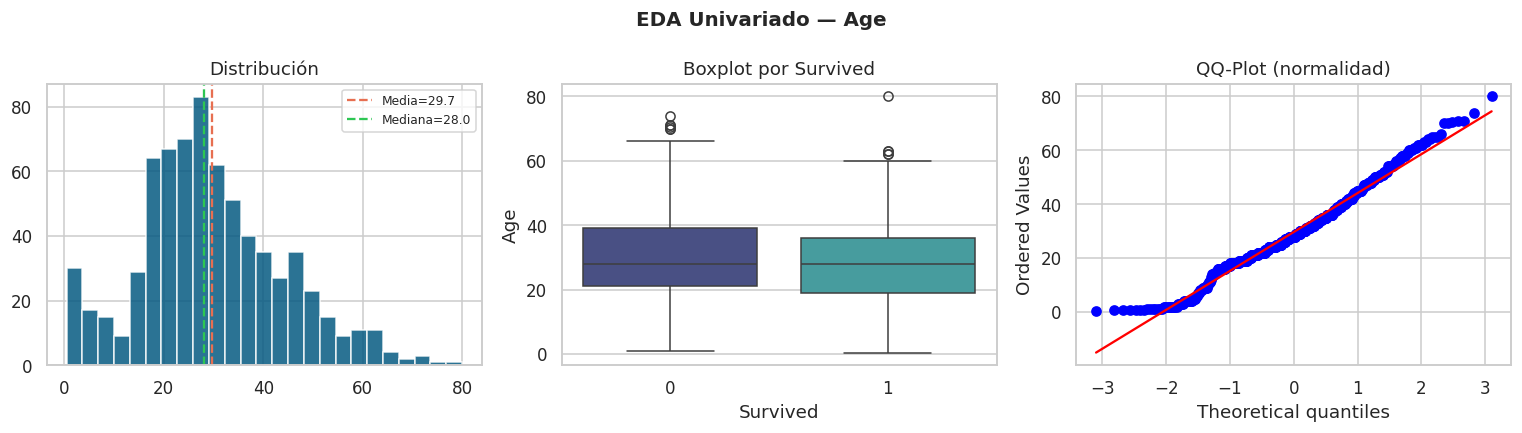

  Skewness: 0.389 | Kurtosis: 0.178
  Outliers IQR: 11 valores


In [ ]:
# ── Aplicar a Age y Fare ──────────────────────────────────────────────
eda_columna(df, "Age", target="Survived")


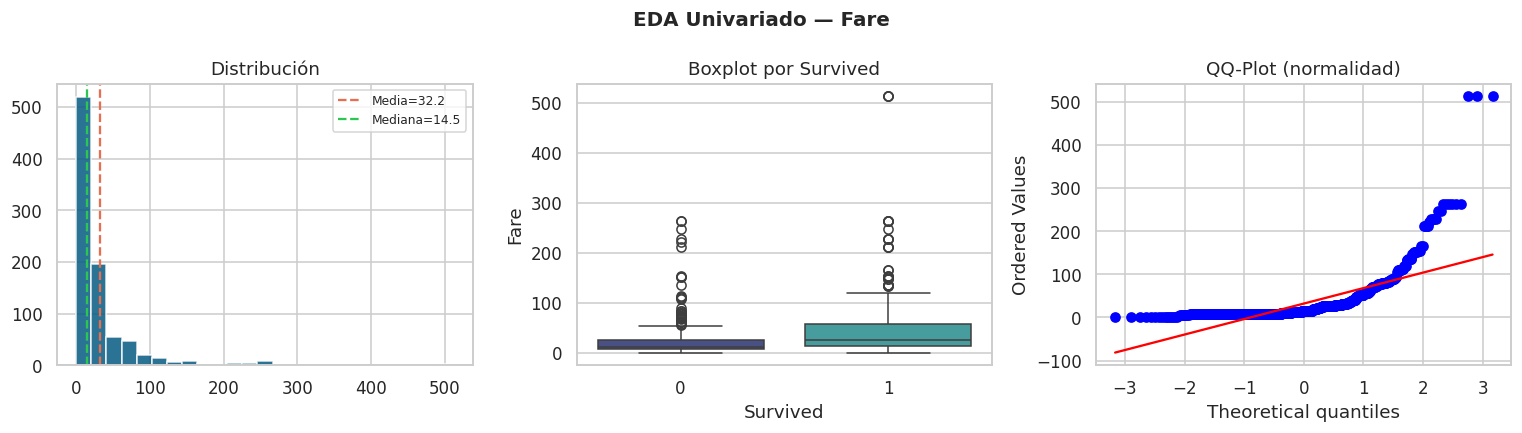

  Skewness: 4.787 | Kurtosis: 33.398
  Outliers IQR: 116 valores


In [ ]:
eda_columna(df, "Fare", target="Survived")


### 3.2 Correlación y Heatmap


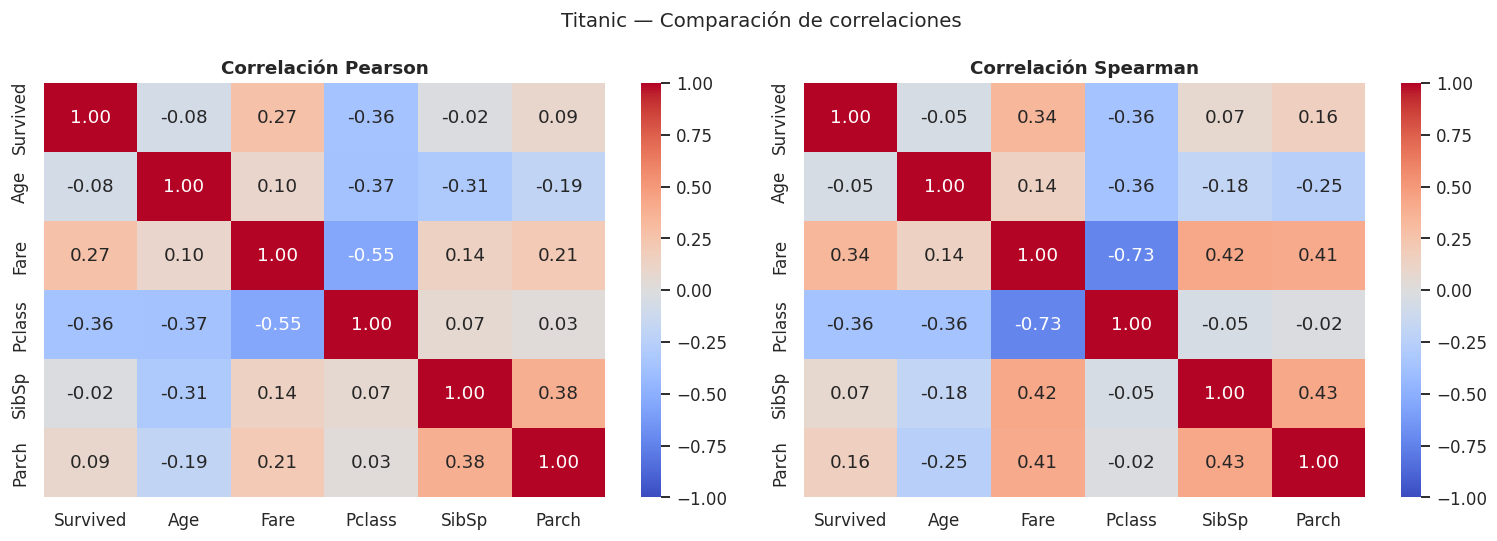

In [ ]:
# ── Pearson vs Spearman ───────────────────────────────────────────────
num_df = df[["Survived", "Age", "Fare", "Pclass", "SibSp", "Parch"]].dropna()

corr_pearson  = num_df.corr(method="pearson")
corr_spearman = num_df.corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(corr_pearson,  annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax1, vmin=-1, vmax=1)
ax1.set_title("Correlación Pearson", fontweight="bold")

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax2, vmin=-1, vmax=1)
ax2.set_title("Correlación Spearman", fontweight="bold")

plt.suptitle("Titanic — Comparación de correlaciones", fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Ejercicio — Análisis multivariado


In [ ]:
# TODO: Creá un crosstab entre "Pclass" y "Survived" y graficalo como heatmap
tabla = pd.crosstab(df["Pclass"], df["Survived"], margins=True)
print("Crosstab Pclass vs Survived:")
display(tabla)

# TODO: ¿Qué clase tiene mayor tasa de supervivencia?
#    R:


Crosstab Pclass vs Survived:


Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


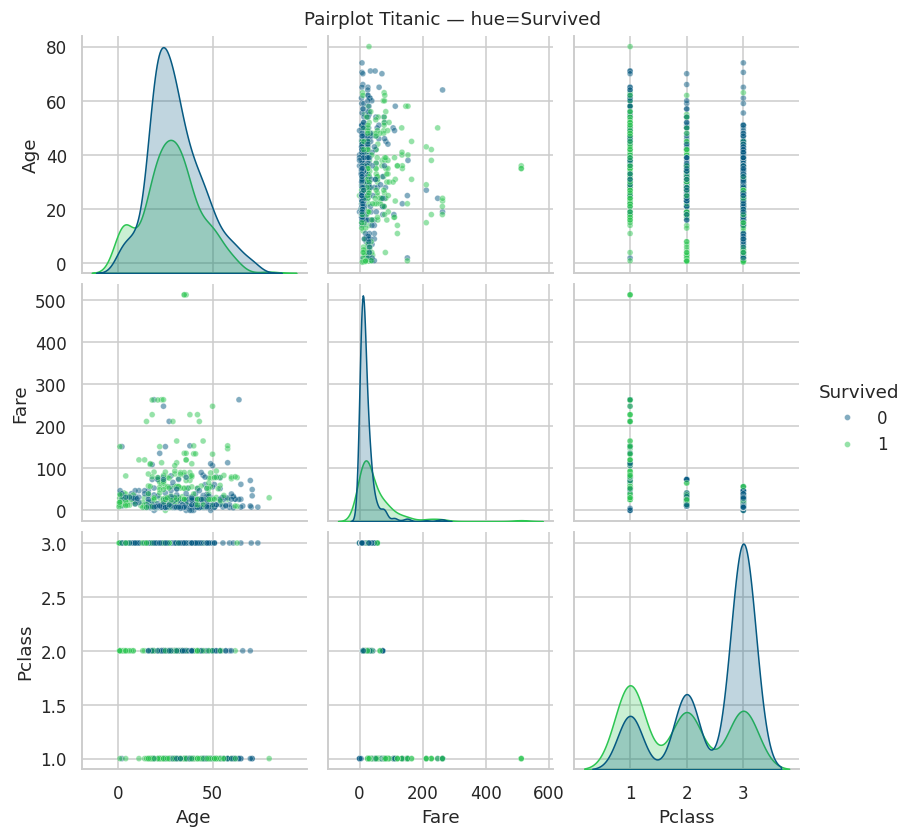

In [ ]:
# TODO: Graficá un pairplot de [Age, Fare, Pclass] con hue="Survived"
# (puede tardar unos segundos)
sns.pairplot(
    df[["Age", "Fare", "Pclass", "Survived"]].dropna(),
    hue="Survived",
    palette={0: "#065A82", 1: "#2DC653"},
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15}
)
plt.suptitle("Pairplot Titanic — hue=Survived", y=1.01, fontsize=12)
plt.show()

# TODO: Describí una relación interesante que observaste en el pairplot
#    R:


---
# 📈 SEMANA 4 — Visualización de Datos

**Temas de la semana:**
- Importancia de la visualización en la toma de decisiones
- Matplotlib y Seaborn: sintaxis y estructura
- Gráficos principales: histogramas, boxplots, scatter, barras, countplot
- Cómo elegir el gráfico correcto según el tipo de variable

### Guía de selección de gráfico
| Objetivo | Gráfico recomendado |
|----------|--------------------|
| Distribución numérica | `histplot` / `kdeplot` |
| Comparar grupos | `boxplot` / `violinplot` |
| Relación entre dos variables | `scatterplot` |
| Conteos categóricos | `countplot` / `barplot` |
| Correlación entre muchas vars | `heatmap` |
| Todas las combinaciones | `pairplot` |


### 4.1 Galería de gráficos sobre Titanic


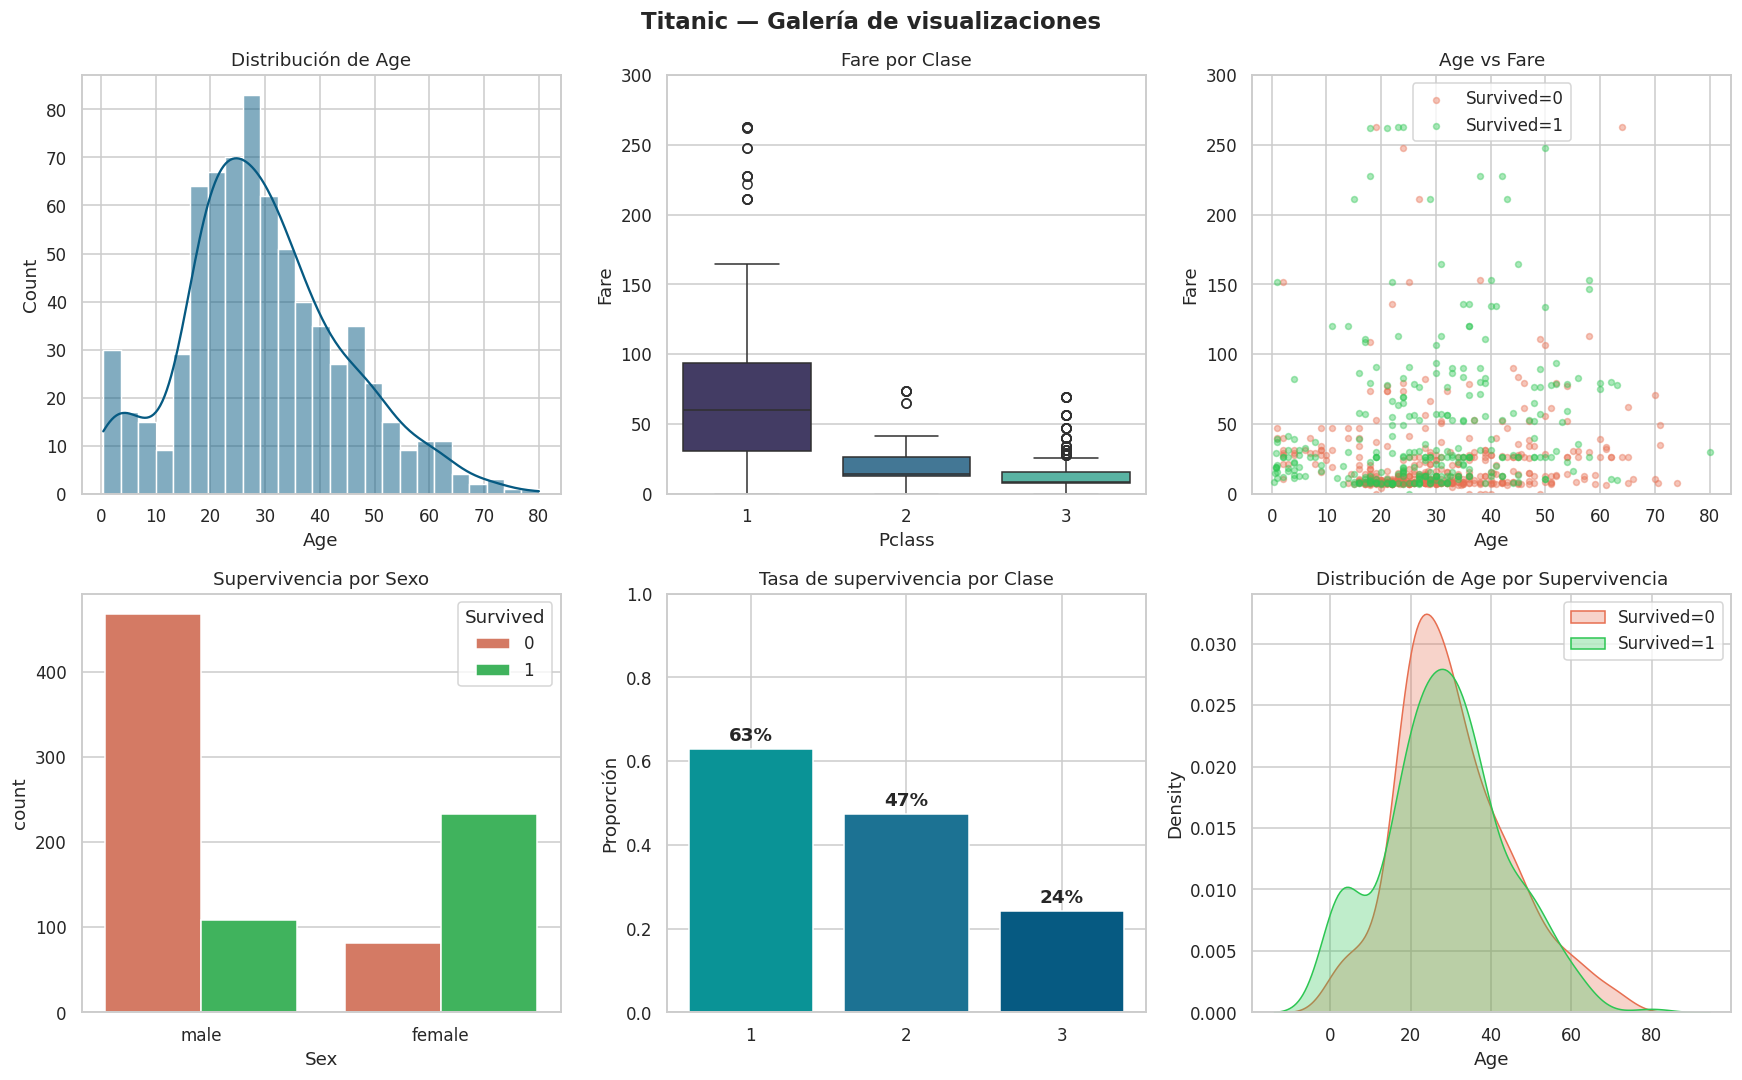

In [ ]:
# ── Panel de visualizaciones principales ─────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Titanic — Galería de visualizaciones", fontsize=15, fontweight="bold")

# 1. Histograma de Age
sns.histplot(df["Age"].dropna(), bins=25, kde=True, ax=axes[0,0], color="#065A82")
axes[0,0].set_title("Distribución de Age")

# 2. Boxplot Fare por Pclass
sns.boxplot(data=df, x="Pclass", y="Fare", ax=axes[0,1], palette="mako")
axes[0,1].set_title("Fare por Clase")
axes[0,1].set_ylim(0, 300)

# 3. Scatter Age vs Fare coloreado por Survived
survived_map = {0: "#E76F51", 1: "#2DC653"}
for s, color in survived_map.items():
    subset = df[df["Survived"] == s]
    axes[0,2].scatter(subset["Age"], subset["Fare"], alpha=0.4, s=15, color=color, label=f"Survived={s}")
axes[0,2].set_xlabel("Age")
axes[0,2].set_ylabel("Fare")
axes[0,2].set_title("Age vs Fare")
axes[0,2].legend()
axes[0,2].set_ylim(0, 300)

# 4. Countplot de Survived por Sex
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[1,0],
              palette={0: "#E76F51", 1: "#2DC653"})
axes[1,0].set_title("Supervivencia por Sexo")

# 5. Barplot tasa de supervivencia por Pclass
surv_class = df.groupby("Pclass")["Survived"].mean().reset_index()
axes[1,1].bar(surv_class["Pclass"].astype(str), surv_class["Survived"],
              color=["#0A9396", "#1C7293", "#065A82"], edgecolor="white")
axes[1,1].set_title("Tasa de supervivencia por Clase")
axes[1,1].set_ylabel("Proporción")
axes[1,1].set_ylim(0, 1)
for i, v in enumerate(surv_class["Survived"]):
    axes[1,1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# 6. KDE Age por Survived
for s, color in survived_map.items():
    sns.kdeplot(df[df["Survived"]==s]["Age"].dropna(), ax=axes[1,2],
               label=f"Survived={s}", color=color, fill=True, alpha=0.3)
axes[1,2].set_title("Distribución de Age por Supervivencia")
axes[1,2].legend()

plt.tight_layout()
plt.show()


### 4.2 Ejercicio — Crear tus propias visualizaciones


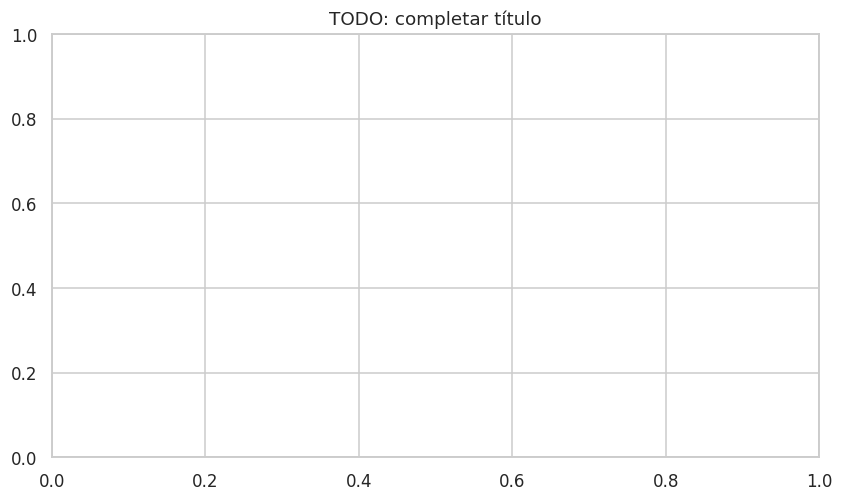

In [ ]:
# TODO 1: Graficá un violinplot de "Age" por "Pclass" con hue="Survived"
# Usá sns.violinplot()
plt.figure(figsize=(9, 5))
# Tu código aquí:


plt.title("TODO: completar título")
plt.show()


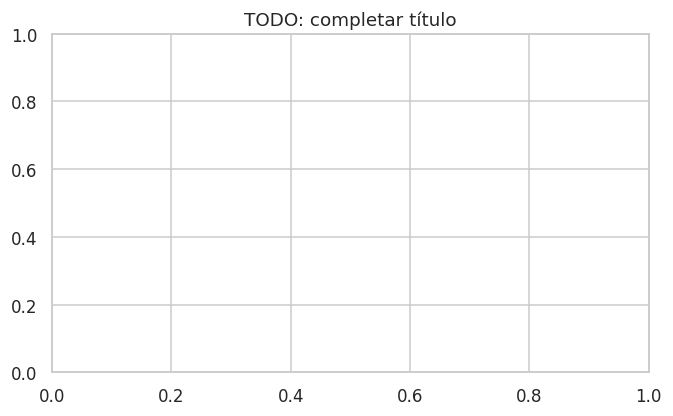

In [ ]:
# TODO 2: Graficá la evolución del precio promedio (Fare) por embarcadero (Embarked)
# Usá un barplot de seaborn con estimator=np.mean
plt.figure(figsize=(7, 4))
# Tu código aquí:


plt.title("TODO: completar título")
plt.show()

# TODO 3: ¿Desde qué embarcadero pagaban más en promedio? ¿A qué puede deberse?
#    R:


---
# 🧹 SEMANA 5 — Preprocesamiento de Datos

**Temas de la semana:**
- Datos faltantes: MCAR, MAR, MNAR — estrategias eliminar vs imputar
- Outliers: conservar, eliminar, winsorizar, transformar
- Normalización MinMaxScaler — Estandarización StandardScaler / RobustScaler
- Codificación: Label Encoding, One-Hot Encoding
- Pipeline de sklearn con ColumnTransformer

### Resumen de decisiones
| Situación | Técnica |
|-----------|--------|
| Pocos nulos (<5%), MCAR | `dropna()` |
| Numérica sin outliers | `SimpleImputer(mean)` |
| Numérica con outliers | `SimpleImputer(median)` |
| Alta correlación entre variables | `KNNImputer` |
| Outliers extremos, ML sensible | Winsorización / log-transform |
| Variables para redes neuronales / SVM | `MinMaxScaler` |
| Variables para regresión / clustering | `StandardScaler` |
| Variables con muchos outliers | `RobustScaler` |
| Variable ordinal / binaria | `LabelEncoder` |
| Variable nominal (3+ categorías) | `OneHotEncoder` |


### 5.1 Diagnóstico de nulos


In [ ]:
# ── Diagnóstico completo de nulos ────────────────────────────────────
def diagnostico_nulos(df):
    total  = df.shape[0]
    nulos  = df.isnull().sum()
    pct    = (nulos / total * 100).round(2)
    dtypes = df.dtypes
    resultado = pd.DataFrame({"Nulos": nulos, "Porcentaje": pct, "Tipo": dtypes})
    return resultado[resultado["Nulos"] > 0].sort_values("Porcentaje", ascending=False)

print("=== Diagnóstico de Nulos — Titanic ===")
display(diagnostico_nulos(df))


=== Diagnóstico de Nulos — Titanic ===


,Nulos,Porcentaje,Tipo
Cabin,687,77.10,object
Age,177,19.87,float64
Embarked,2,0.22,object


### 5.2 Imputación


In [ ]:
from sklearn.impute import SimpleImputer, KNNImputer

# Copias para no modificar el original
df_imp = df.copy()

# Age: mediana (hay outliers visibles en boxplot)
imp_median = SimpleImputer(strategy="median")
df_imp["Age"] = imp_median.fit_transform(df_imp[["Age"]])

# Embarked: moda (categórica, 2 nulos solamente)
imp_moda = SimpleImputer(strategy="most_frequent")
df_imp["Embarked"] = imp_moda.fit_transform(df_imp[["Embarked"]]).ravel()

# Cabin: 77% nulos → eliminar columna
df_imp.drop(columns=["Cabin"], inplace=True)

print("Nulos restantes:")
print(df_imp.isnull().sum()[df_imp.isnull().sum() > 0])
print("\n✅ Sin nulos relevantes" if df_imp.isnull().sum().sum() == 0 else "")


Nulos restantes:
Series([], dtype: int64)

✅ Sin nulos relevantes


### 5.3 Outliers — Detección y tratamiento


In [ ]:
# ── Detección por IQR ────────────────────────────────────────────────
def detectar_outliers_iqr(serie):
    q1  = serie.quantile(0.25)
    q3  = serie.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = serie[(serie < lower) | (serie > upper)]
    return lower, upper, outliers

for col in ["Age", "Fare", "SibSp"]:
    low, up, out = detectar_outliers_iqr(df_imp[col])
    print(f"{col}: límites=[{low:.1f}, {up:.1f}] → {len(out)} outliers ({len(out)/len(df_imp)*100:.1f}%)")


Age: límites=[2.5, 54.5] → 66 outliers (7.4%)
Fare: límites=[-26.7, 65.6] → 116 outliers (13.0%)
SibSp: límites=[-1.5, 2.5] → 46 outliers (5.2%)


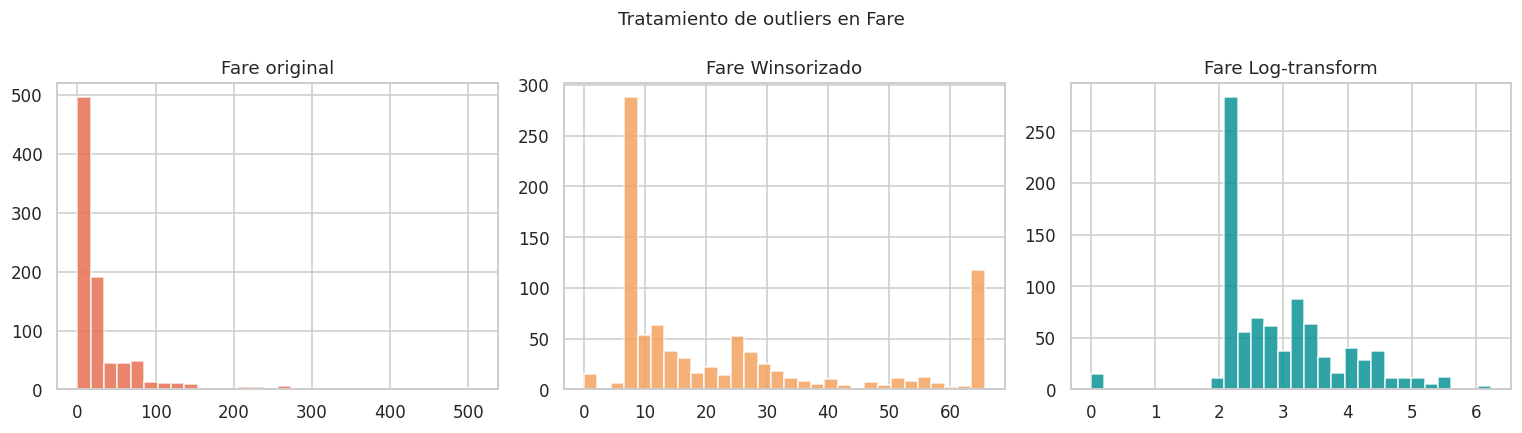

Skewness original:    4.787
Skewness winsorizado: 1.082
Skewness log:         0.395


In [ ]:
# ── Comparación de tratamientos en Fare ──────────────────────────────
fare = df_imp["Fare"].copy()

# Winsorización
low, up, _ = detectar_outliers_iqr(fare)
fare_wins = fare.clip(lower=low, upper=up)

# Log transform
fare_log = np.log1p(fare)  # log(1 + x) para manejar ceros

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(fare,      bins=30, color="#E76F51", edgecolor="white", alpha=0.85)
axes[0].set_title("Fare original")

axes[1].hist(fare_wins, bins=30, color="#F4A261", edgecolor="white", alpha=0.85)
axes[1].set_title("Fare Winsorizado")

axes[2].hist(fare_log,  bins=30, color="#0A9396", edgecolor="white", alpha=0.85)
axes[2].set_title("Fare Log-transform")

plt.suptitle("Tratamiento de outliers en Fare", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Skewness original:    {fare.skew():.3f}")
print(f"Skewness winsorizado: {fare_wins.skew():.3f}")
print(f"Skewness log:         {fare_log.skew():.3f}")


### 5.4 Escalado


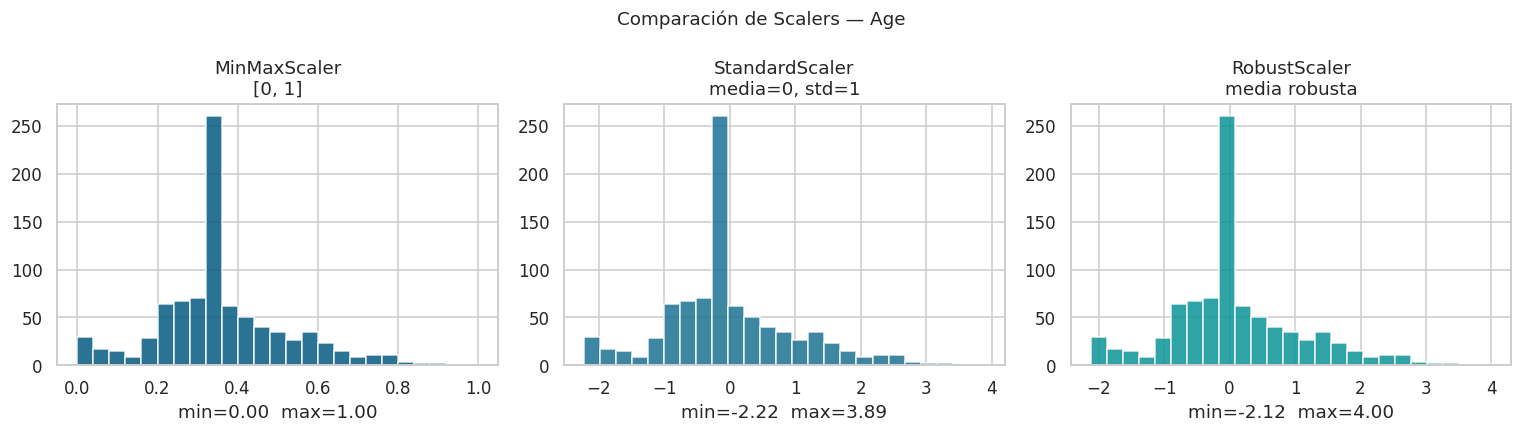

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

age_clean = df_imp["Age"].values.reshape(-1, 1)

age_minmax   = MinMaxScaler().fit_transform(age_clean).ravel()
age_standard = StandardScaler().fit_transform(age_clean).ravel()
age_robust   = RobustScaler().fit_transform(age_clean).ravel()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

datos = [age_minmax, age_standard, age_robust]
titulos = ["MinMaxScaler\n[0, 1]", "StandardScaler\nmedia=0, std=1", "RobustScaler\nmedia robusta"]
colores = ["#065A82", "#1C7293", "#0A9396"]

for ax, d, t, c in zip(axes, datos, titulos, colores):
    ax.hist(d, bins=25, color=c, edgecolor="white", alpha=0.85)
    ax.set_title(t)
    ax.set_xlabel(f"min={d.min():.2f}  max={d.max():.2f}")

plt.suptitle("Comparación de Scalers — Age", fontsize=12)
plt.tight_layout()
plt.show()


### 5.5 Codificación y Pipeline


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── LabelEncoder para "Sex" (binaria) ────────────────────────────────
le = LabelEncoder()
df_imp["Sex_enc"] = le.fit_transform(df_imp["Sex"])
print("Sex encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── One-Hot Encoding para "Embarked" (nominal) ────────────────────────
print("\nEmbarked antes:", df_imp["Embarked"].value_counts().to_dict())
embarked_dummies = pd.get_dummies(df_imp["Embarked"], prefix="Emb", drop_first=True)
print("Columnas generadas:", embarked_dummies.columns.tolist())
display(embarked_dummies.head())


Sex encoding: {'female': np.int64(0), 'male': np.int64(1)}

Embarked antes: {'S': 646, 'C': 168, 'Q': 77}
Columnas generadas: ['Emb_Q', 'Emb_S']


,Emb_Q,Emb_S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [ ]:
# ── Pipeline completo con ColumnTransformer ───────────────────────────
features = ["Age", "Fare", "Pclass", "SibSp", "Parch", "Sex", "Embarked"]
df_pipe = df[features].copy()
df_pipe["Embarked"] = df_pipe["Embarked"].fillna("S")

num_cols_pipe = ["Age", "Fare", "Pclass", "SibSp", "Parch"]
cat_cols_pipe = ["Sex", "Embarked"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols_pipe),
    ("cat", cat_pipeline, cat_cols_pipe)
])

X_processed = preprocessor.fit_transform(df_pipe)
print(f"Shape original:    {df_pipe.shape}")
print(f"Shape procesado:   {X_processed.shape}")
print("\n✅ Pipeline ejecutado exitosamente")


Shape original:    (891, 7)
Shape procesado:   (891, 8)

✅ Pipeline ejecutado exitosamente


### 5.6 Ejercicio — Decisiones de preprocesamiento


In [ ]:
# TODO: Completá la tabla de decisiones para cada columna del Titanic
# Ejecutá la celda para ver el template y completá los comentarios

columnas_analizar = {
    "Age":      {"nulos": "19%", "tipo": "numérica",   "decision_nulos": "TODO", "scaler": "TODO", "encoding": "N/A"},
    "Fare":     {"nulos": "0%",  "tipo": "numérica",   "decision_nulos": "N/A",  "scaler": "TODO", "encoding": "N/A"},
    "Embarked": {"nulos": "0.2%","tipo": "categórica", "decision_nulos": "TODO", "scaler": "N/A",  "encoding": "TODO"},
    "Sex":      {"nulos": "0%",  "tipo": "binaria",    "decision_nulos": "N/A",  "scaler": "N/A",  "encoding": "TODO"},
    "Cabin":    {"nulos": "77%", "tipo": "categórica", "decision_nulos": "TODO", "scaler": "N/A",  "encoding": "TODO"},
}

pd.DataFrame(columnas_analizar).T


,nulos,tipo,decision_nulos,scaler,encoding
Age,19%,numérica,TODO,TODO,N/A
Fare,0%,numérica,N/A,TODO,N/A
Embarked,0.2%,categórica,TODO,N/A,TODO
Sex,0%,binaria,N/A,N/A,TODO
Cabin,77%,categórica,TODO,N/A,TODO


---
# 🔵 SEMANA 6 — Técnicas de Clustering

**Temas de la semana:**
- ¿Qué es el clustering? Aprendizaje no supervisado
- K-Means: centroides, inercia, Elbow Method
- DBSCAN: épsilon, min_samples, puntos ruido
- SOM (Self-Organizing Maps): redes neuronales para clustering
- Métricas de evaluación: Silhouette Score, Davies-Bouldin

### Diferencias entre algoritmos
| Algoritmo | Tipo | Necesita K | Maneja ruido | Forma de clusters |
|-----------|------|-----------|-------------|-------------------|
| K-Means | Centroide | ✅ Sí | ❌ No | Esférica |
| DBSCAN | Densidad | ❌ No | ✅ Sí | Arbitraria |
| SOM | Neuronal | ✅ Sí (grilla) | ❌ No | Topológica |

*Usaremos el dataset **Wine** (características físico-químicas de vinos) para clustering.*


### 6.1 Exploración del dataset Wine


In [ ]:
# ── Dataset Wine — no usamos "variedad" en el clustering ─────────────
print(f"Shape: {df_wine.shape}")
display(df_wine.head())
print("\nEstadística descriptiva:")
display(df_wine.drop(columns="variedad").describe().round(2))


Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,variedad
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Estadística descriptiva:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [ ]:
# ── Preprocesamos: escalado obligatorio para K-Means ─────────────────
from sklearn.preprocessing import StandardScaler

X_wine = df_wine.drop(columns="variedad")
X_wine_scaled = StandardScaler().fit_transform(X_wine)

print(f"Shape para clustering: {X_wine_scaled.shape}")
print("Escalado aplicado: StandardScaler (media=0, std=1)")


Shape para clustering: (178, 13)
Escalado aplicado: StandardScaler (media=0, std=1)


### 6.2 K-Means — Elbow Method


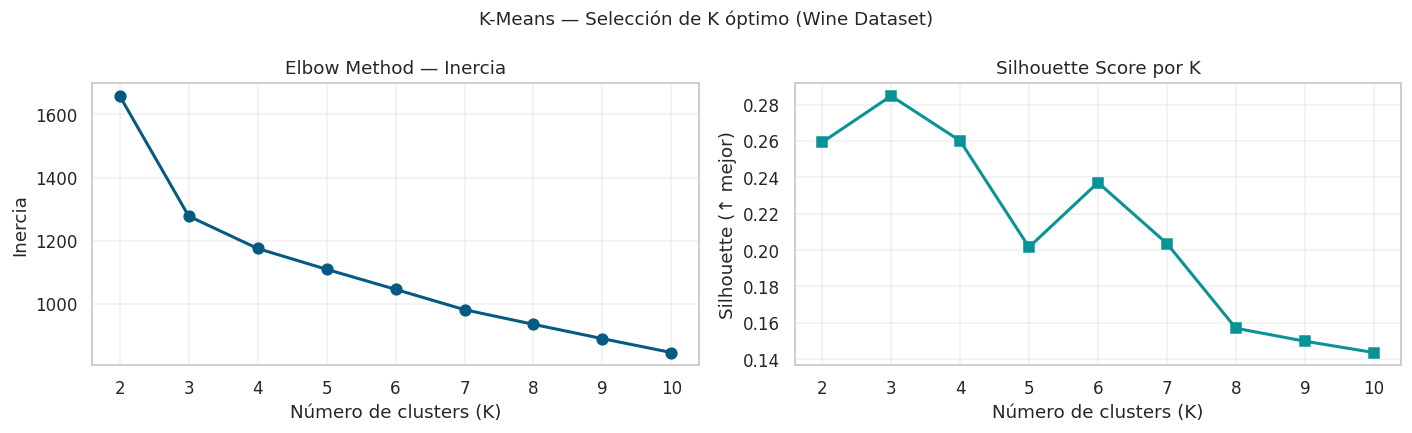

K con mayor Silhouette: 3 (score=0.2849)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ── Elbow Method: buscar el K óptimo ─────────────────────────────────
inercias = []
silhouettes = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_wine_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_wine_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(rango_k, inercias, "o-", color="#065A82", linewidth=2, markersize=7)
ax1.set_title("Elbow Method — Inercia")
ax1.set_xlabel("Número de clusters (K)")
ax1.set_ylabel("Inercia")
ax1.grid(True, alpha=0.3)

ax2.plot(rango_k, silhouettes, "s-", color="#0A9396", linewidth=2, markersize=7)
ax2.set_title("Silhouette Score por K")
ax2.set_xlabel("Número de clusters (K)")
ax2.set_ylabel("Silhouette (↑ mejor)")
ax2.grid(True, alpha=0.3)

plt.suptitle("K-Means — Selección de K óptimo (Wine Dataset)", fontsize=12)
plt.tight_layout()
plt.show()

mejor_k = rango_k[silhouettes.index(max(silhouettes))]
print(f"K con mayor Silhouette: {mejor_k} (score={max(silhouettes):.4f})")


### 6.3 K-Means con K óptimo — Visualización


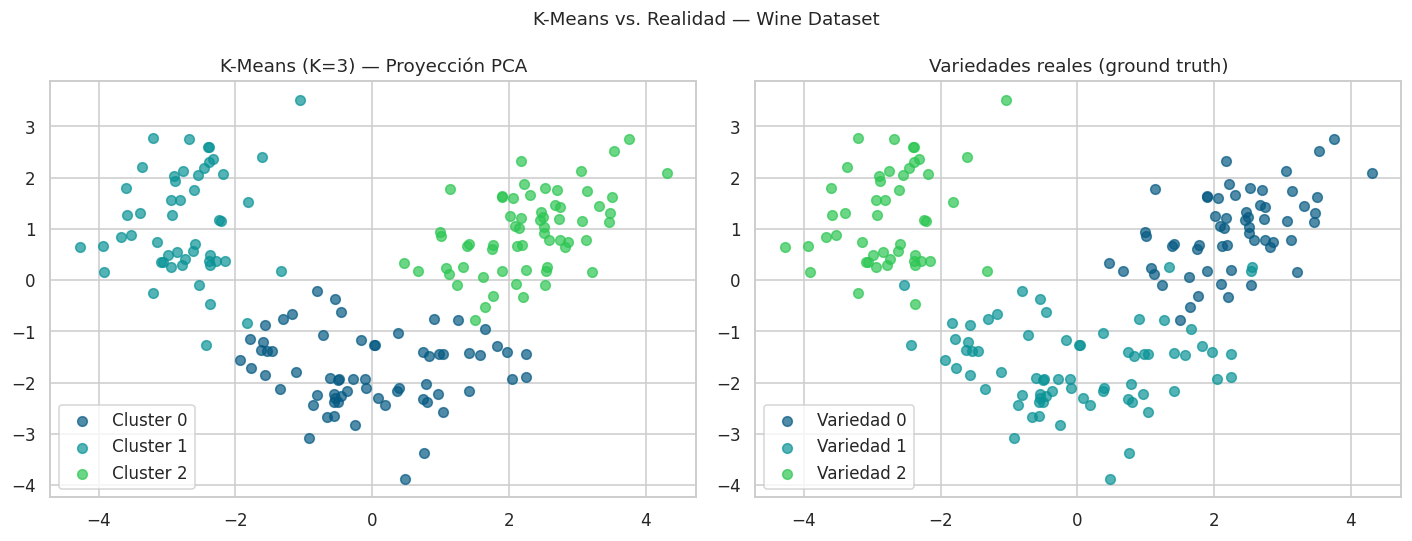

Silhouette Score: 0.2849  (↑ mejor, max=1)
Davies-Bouldin:   1.3892   (↓ mejor, min=0)


In [ ]:
# ── Aplicar K-Means con el K elegido ─────────────────────────────────
K_OPTIMO = 3  # Wine tiene 3 variedades reales — veamos si el clustering las recupera

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_wine_scaled)

# PCA para visualizar en 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_wine_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colores = ["#065A82", "#0A9396", "#2DC653"]

# Clusters K-Means
for k in range(K_OPTIMO):
    mask = labels_km == k
    ax1.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colores[k], label=f"Cluster {k}", alpha=0.7, s=40)
ax1.set_title(f"K-Means (K={K_OPTIMO}) — Proyección PCA")
ax1.legend()

# Variedades reales
for v in range(3):
    mask = df_wine["variedad"].values == v
    ax2.scatter(X_2d[mask, 0], X_2d[mask, 1], c=colores[v], label=f"Variedad {v}", alpha=0.7, s=40)
ax2.set_title("Variedades reales (ground truth)")
ax2.legend()

plt.suptitle("K-Means vs. Realidad — Wine Dataset", fontsize=12)
plt.tight_layout()
plt.show()

sil = silhouette_score(X_wine_scaled, labels_km)
db  = davies_bouldin_score(X_wine_scaled, labels_km)
print(f"Silhouette Score: {sil:.4f}  (↑ mejor, max=1)")
print(f"Davies-Bouldin:   {db:.4f}   (↓ mejor, min=0)")


### 6.4 DBSCAN — Clustering por densidad


Clusters encontrados: 0
Puntos ruido (-1):    178 (100.0%)
Distribución: {np.int64(-1): np.int64(178)}


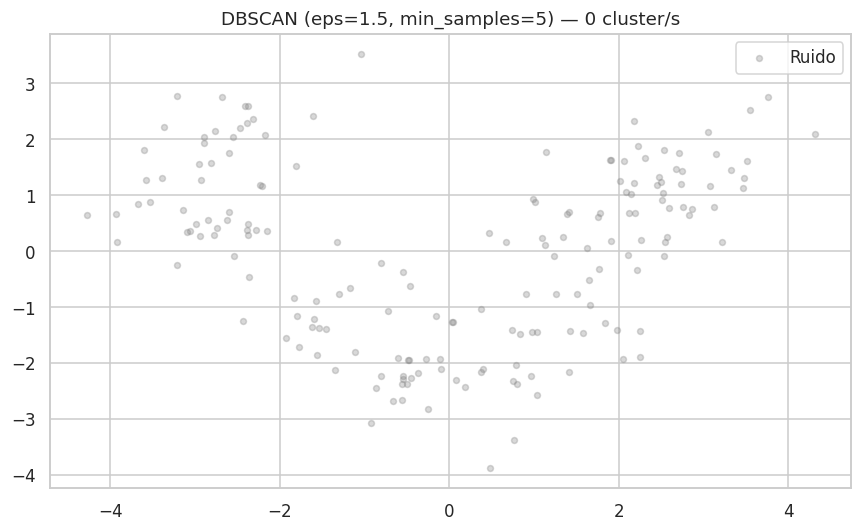

In [ ]:
from sklearn.cluster import DBSCAN

# ── DBSCAN: epsilon y min_samples ────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels_db = dbscan.fit_predict(X_wine_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido    = (labels_db == -1).sum()

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos ruido (-1):    {n_ruido} ({n_ruido/len(labels_db)*100:.1f}%)")
print(f"Distribución: {dict(zip(*np.unique(labels_db, return_counts=True)))}")

# Visualización
plt.figure(figsize=(8, 5))
palette = {-1: "gray", 0: "#065A82", 1: "#0A9396", 2: "#2DC653"}
for lbl in sorted(set(labels_db)):
    mask = labels_db == lbl
    label_name = "Ruido" if lbl == -1 else f"Cluster {lbl}"
    color = palette.get(lbl, "#F4A261")
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label_name,
                alpha=0.6 if lbl != -1 else 0.3, s=40 if lbl != -1 else 15)
plt.title(f"DBSCAN (eps=1.5, min_samples=5) — {n_clusters} cluster/s")
plt.legend()
plt.tight_layout()
plt.show()


### 6.5 Ejercicio — Comparación de algoritmos


In [ ]:
# TODO 1: Probá DBSCAN con diferentes valores de eps (0.5, 1.0, 2.0)
# ¿Cómo cambia el número de clusters y de puntos ruido?

resultados = []
for eps_val in [0.5, 1.0, 1.5, 2.0, 3.0]:
    db = DBSCAN(eps=eps_val, min_samples=5)
    lbl = db.fit_predict(X_wine_scaled)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_ru = (lbl == -1).sum()
    resultados.append({"eps": eps_val, "clusters": n_cl, "ruido": n_ru})

df_dbscan = pd.DataFrame(resultados)
display(df_dbscan)

# TODO 2: ¿Cuál eps te parece más adecuado para este dataset? ¿Por qué?
#    R:


,eps,clusters,ruido
0,0.5,0,178
1,1.0,0,178
2,1.5,0,178
3,2.0,5,85
4,3.0,1,11


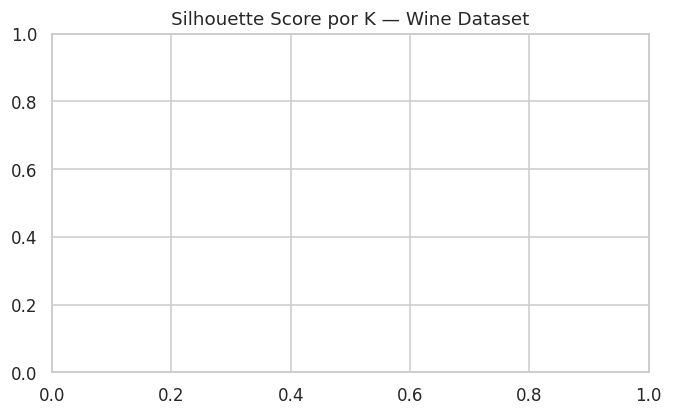

In [ ]:
# TODO 3: Calculá el Silhouette Score para cada K de K-Means (ya lo tenés en silhouettes)
# y grafiá un barplot comparando Silhouette para K=2,3,4,5

df_sil = pd.DataFrame({"K": list(rango_k), "Silhouette": silhouettes})
df_sil_subset = df_sil[df_sil["K"] <= 5]

plt.figure(figsize=(7, 4))
# Tu código aquí (barplot):


plt.title("Silhouette Score por K — Wine Dataset")
plt.show()

# TODO 4: ¿Por qué no se puede usar Silhouette Score para comparar K-Means vs DBSCAN
#          directamente cuando DBSCAN tiene puntos ruido?
#    R:


---
# 🎯 INTEGRADOR FINAL — Pipeline completo S1→S6

En este bloque vas a aplicar **todo lo visto** en un flujo encadenado:
Exploración → Estadística → EDA → Visualización → Preprocesamiento → Clustering


In [ ]:
# ── Flujo integrado sobre Titanic ────────────────────────────────────

# S1: Carga e inspección inicial
print("=== S1: INSPECCIÓN INICIAL ===")
print(f"Shape: {df.shape} | Nulos: {df.isnull().sum().sum()}")

# S2: Estadística
print("\n=== S2: ESTADÍSTICA (Age y Fare) ===")
print(df[["Age", "Fare"]].describe().round(2))

# S3: Correlación
print("\n=== S3: TOP 3 CORRELACIONES CON SURVIVED ===")
corr_survived = df[["Survived", "Age", "Fare", "Pclass", "SibSp"]].corr()["Survived"].abs().sort_values(ascending=False)
print(corr_survived)


=== S1: INSPECCIÓN INICIAL ===
Shape: (891, 12) | Nulos: 866

=== S2: ESTADÍSTICA (Age y Fare) ===
          Age    Fare
count  714.00  891.00
mean    29.70   32.20
std     14.53   49.69
min      0.42    0.00
25%     20.12    7.91
50%     28.00   14.45
75%     38.00   31.00
max     80.00  512.33

=== S3: TOP 3 CORRELACIONES CON SURVIVED ===
Survived    1.000000
Pclass      0.338481
Fare        0.257307
Age         0.077221
SibSp       0.035322
Name: Survived, dtype: float64


=== S4: VISUALIZACIÓN ===


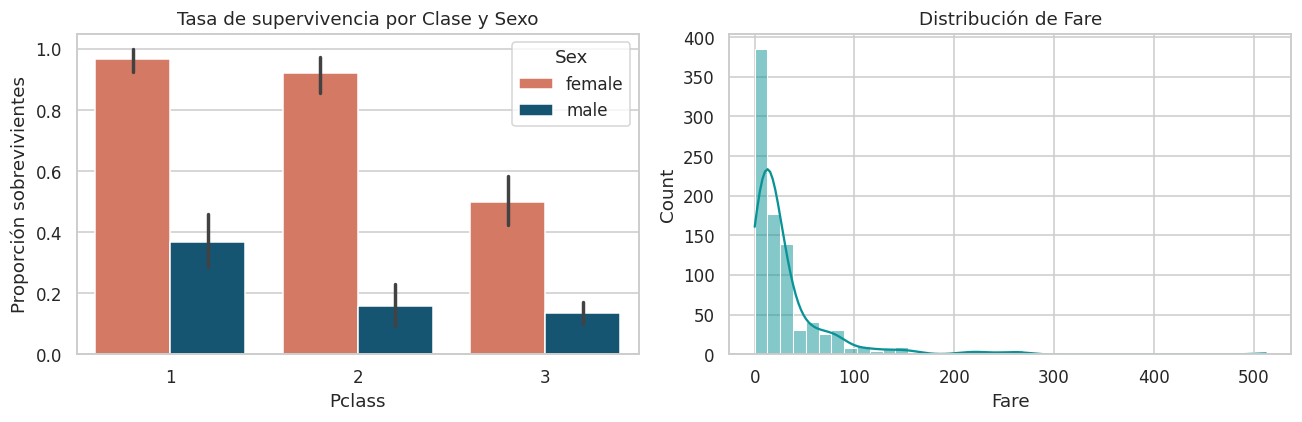

In [ ]:
# S4: Visualización rápida
print("=== S4: VISUALIZACIÓN ===")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x="Pclass", y="Survived", hue="Sex",
            palette={"male": "#065A82", "female": "#E76F51"}, ax=ax1)
ax1.set_title("Tasa de supervivencia por Clase y Sexo")
ax1.set_ylabel("Proporción sobrevivientes")

sns.histplot(df["Fare"], bins=40, kde=True, ax=ax2, color="#0A9396")
ax2.set_title("Distribución de Fare")

plt.tight_layout()
plt.show()


In [ ]:
# S5: Preprocesamiento y S6: Clustering sobre pasajeros del Titanic
print("=== S5+S6: PREPROCESAMIENTO + CLUSTERING EN TITANIC ===")

# Seleccionar features numéricas relevantes
cols_cluster = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
df_cluster = df[cols_cluster].dropna()
print(f"Filas con datos completos: {len(df_cluster)}")

# Escalar
X_cluster = StandardScaler().fit_transform(df_cluster)

# K-Means con K=3 (barato/medio/caro aproximado)
km_titanic = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km_titanic.fit_predict(X_cluster)
df_cluster = df_cluster.copy()
df_cluster["Cluster"] = clusters

# Perfil de cada cluster
print("\nPerfil promedio por cluster:")
display(df_cluster.groupby("Cluster").mean().round(2))

sil = silhouette_score(X_cluster, clusters)
print(f"\nSilhouette Score: {sil:.4f}")


=== S5+S6: PREPROCESAMIENTO + CLUSTERING EN TITANIC ===
Filas con datos completos: 714

Perfil promedio por cluster:


,Pclass,Age,SibSp,Parch,Fare
Cluster,,,,,
0,1.11,40.89,0.40,0.32,75.85
1,2.71,28.20,0.22,0.14,12.52
2,2.51,13.64,1.98,1.90,45.77



Silhouette Score: 0.3810


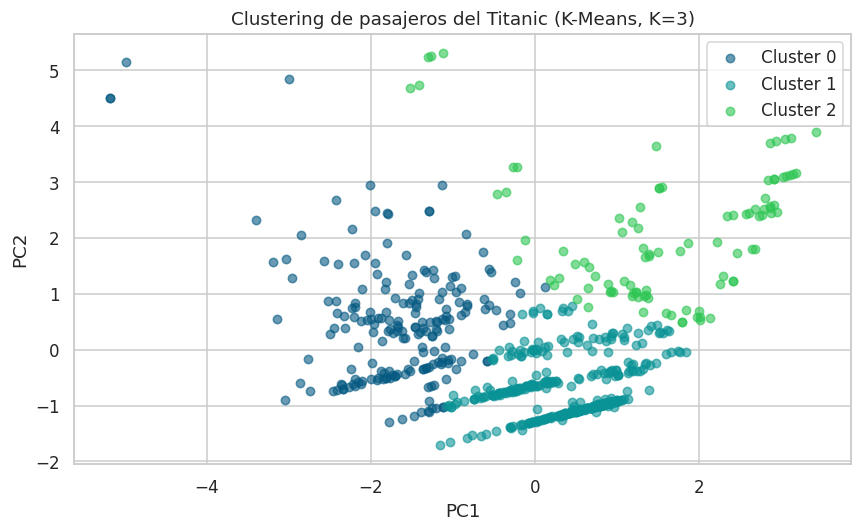

In [ ]:
# ── Visualización 2D de clusters (PCA) ───────────────────────────────
pca_t = PCA(n_components=2, random_state=42)
X_2d_t = pca_t.fit_transform(X_cluster)

plt.figure(figsize=(8, 5))
colores_t = ["#065A82", "#0A9396", "#2DC653"]
for k in range(3):
    mask = clusters == k
    plt.scatter(X_2d_t[mask, 0], X_2d_t[mask, 1],
                c=colores_t[k], label=f"Cluster {k}", alpha=0.6, s=30)
plt.title("Clustering de pasajeros del Titanic (K-Means, K=3)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

# TODO: Describí con tus palabras qué representa cada cluster en términos de pasajeros
#   Cluster 0:
#   Cluster 1:
#   Cluster 2:


---
## 💬 Reflexión Final

Respondé las siguientes preguntas en comentarios dentro de la celda de código:


In [ ]:
# REFLEXIÓN FINAL

# 1. De todas las semanas vistas (S1-S6), ¿cuál concepto te resultó más difícil de entender?
#    ¿Qué hiciste para intentar comprenderlo mejor?
#    R:

# 2. En el proceso KDD, ¿cuál etapa te parece la más crítica y por qué?
#    R:

# 3. Al aplicar K-Means al Titanic obtuviste 3 clusters.
#    ¿Tiene sentido separar a los pasajeros en 3 grupos? ¿Qué haría diferente?
#    R:

# 4. ¿Qué situación del mundo real se te ocurre donde aplicarías clustering?
#    Describí brevemente el dataset, las features y qué esperarías encontrar.
#    R:


---
<div style="background:#0D1B2A;color:#8BADC0;padding:20px 30px;border-radius:10px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:12px;letter-spacing:2px;margin:0 0 8px 0;">MINERÍA DE DATOS · 2026 · SEMANA 7</p>
  <p style="font-size:15px;color:#FFFFFF;margin:0 0 6px 0;"><strong>Repaso integral completado</strong></p>
  <p style="font-size:13px;margin:0;">S1: Intro/KDD · S2: Estadística · S3: EDA · S4: Visualización · S5: Preprocesamiento · S6: Clustering</p>
  <hr style="border:1px solid #1C7293;margin:14px 0;">
  <p style="font-size:12px;margin:0;color:#8BADC0;">Tecnicatura en Informática · Politécnico Malvinas Argentinas</p>
</div>
